# ST2195 Coursework

# Question 1a-2c

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import os
import seaborn as sns

In [4]:
current_directory = os.getcwd()
print("Current working directory:", current_directory)

Current working directory: C:\Users\user\Downloads


# Q1a

In [8]:
def f(x):
    return 0.5 * np.exp(-np.abs(x))

In [17]:
def MH(N, s, initial_x):
    x = np.zeros(N)
    s>0
    x[0] = initial_x
    
    for i in range(1, N):
        mean = x[i-1] # Mean of the normal distribution
        std_dev = s # Standard deviation of the normal distribution
        x_star = np.random.normal(loc=mean, scale=std_dev)
        ratio = f(x_star) / f(x[i-1])
        u = np.random.uniform(0,1)
        if np.log(u) < np.log(ratio):
            x[i] = x_star
        else:
            x[i] = x[i-1]
    return x

In [18]:
N = 10000
s = 1
initial_x = 0

In [19]:
generated_samples = MH(N, s, initial_x)

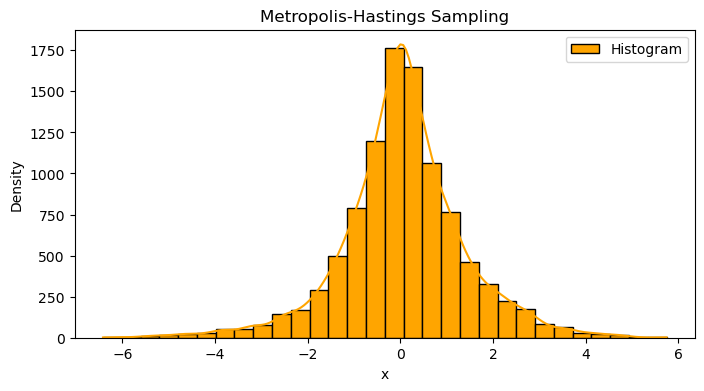

In [39]:
plt.figure(figsize=(8, 4))
sns.histplot(generated_samples, bins=30, kde=True, color='orange', alpha=1,label='Histogram')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Metropolis-Hastings Sampling')
plt.legend()


In [42]:
# Calculate sample mean and standard deviation
sample_mean = np.mean(generated_samples)
sample_std = np.std(generated_samples)
print("Sample Mean:", sample_mean)
print("Sample Standard Deviation:", sample_std)



Sample Mean: 0.05755516523766179
Sample Standard Deviation: 1.3294681230548453


# Q1b

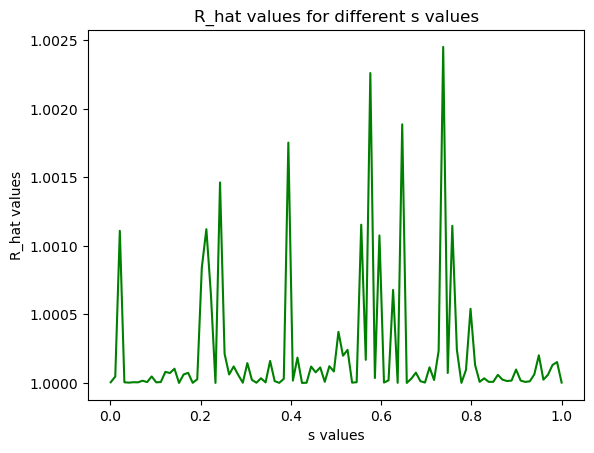

In [75]:
def check_R_hat(chains):
    Mj = np.mean(chains,axis=1)
    Vj = np.var(chains, axis=1, ddof=1)
    W = np.var(Vj,ddof=1)
    M = np.mean(Mj)
    B = np.var((Mj-M)**2, ddof=1)
    R_hat = np.sqrt((B + W) / W)
    return R_hat

def generate_chains(J, N, s):
    chains = np.random.normal(0, s, size=(J, N))
    return chains

# Define the parameters
N = 2000
s_values = np.linspace(0.001, 1, 100)
J = 4
R_hat_values = []

for s in s_values:
    chains = generate_chains(J, N, s)
    R_hat_value = check_R_hat(chains)  # Calculate R_hat
    R_hat_values.append(R_hat_value)  # Store R_hat

# Plot R_hat values
plt.plot(s_values, R_hat_values, color="green")
plt.xlabel('s values')
plt.ylabel('R_hat values')
plt.title('R_hat values for different s values')
plt.show()

# Q2

In [2]:
conn = sqlite3.connect('airline.db')

In [3]:
airports = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\airports.csv")
planes = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\plane-data.csv")
carriers = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\carriers.csv")

In [4]:
airports.to_sql('airports', con = conn, index = False,if_exists = 'replace')
planes.to_sql('planes', con = conn, index = False,if_exists = 'replace')
carriers.to_sql('carriers',con=conn,index = False,if_exists = 'replace')

1491

In [5]:
# Establish a connection to the database
conn = sqlite3.connect('flight.db')

# Check if the connection is established
if conn:
    print("Connection is established.")
else:
    print("Failed to establish connection.")


Connection is established.


In [6]:
c = conn.cursor()
c.execute('''
CREATE TABLE flights (
  Year int,
  Month int,
  DayofMonth int,
  DayOfWeek int,
  DepTime  int,
  CRSDepTime int,
  ArrTime int,
  CRSArrTime int,
  UniqueCarrier varchar(5),
  FlightNum int,
  TailNum varchar(8),
  ActualElapsedTime int,
  CRSElapsedTime int,
  AirTime int,
  ArrDelay int,
  DepDelay int,
  Origin varchar(3),
  Dest varchar(3),
  Distance int,
  TaxiIn int,
  TaxiOut int,
  Cancelled int,
  CancellationCode varchar(1),
  Diverted varchar(1),
  CarrierDelay int,
  WeatherDelay int,
  NASDelay int,
  SecurityDelay int,
  LateAircraftDelay int
)
''')
conn.commit()#done

OperationalError: table flights already exists

In [7]:
data1998 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\1998.csv")
data1999 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\1999.csv")
data2000 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2000.csv")
data2001 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2001.csv",encoding='latin1') 
data2002 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2002.csv",encoding='latin1')
data2003 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2003.csv",encoding='latin1',dtype={22: str})
data2004 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2004.csv",encoding='latin1')
data2005 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2005.csv",encoding='latin1')
data2006 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2006.csv",encoding='latin1')
data2007 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2007.csv",encoding='latin1')
#done

In [ ]:
data1998.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data1999.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data2000.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data2001.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data2002.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data2003.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data2004.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data2005.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data2006.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)
data2007.to_sql('flights', con = conn, if_exists = 'append', index = False,chunksize=5000)


## Q2a

# Best time of day

In [10]:
TimeLeastDelay = c.execute('''
 SELECT DepTime
 FROM flights
 WHERE flights.Cancelled = 0 AND Diverted = 0 AND DepDelay > 0
 ORDER BY DepDelay
''')
pd.DataFrame(TimeLeastDelay)

""


In [11]:
TimeLeastDelay = c.execute('''
 SELECT DepTime
 FROM flights
 WHERE flights.Cancelled = 0 AND Diverted = 0 AND DepDelay > 0
 ORDER BY DepDelay
''')

# Fetch all rows from the cursor
rows = TimeLeastDelay.fetchall()

# Create a DataFrame
df = pd.DataFrame(rows, columns=['DepTime'])


In [94]:
TimeNoDelay = c.execute('''
 SELECT DepTime, Count(*) AS total
 FROM flights
 WHERE flights.Cancelled = 0 AND Diverted = 0 AND DepDelay == 0
 GROUP BY DepTime
 ORDER BY total
''')
pd.DataFrame(TimeNoDelay)

,0,1
0,141,1
1,203,1
2,229,1
3,232,1
4,238,1
...,...,...
1318,730,97064
1319,600,116769
1320,800,118289
1321,630,143317


# Best day of week

In [97]:
DayLeastDelay = c.execute('''
 SELECT DayofWeek
 FROM flights
 WHERE flights.Cancelled = 0 AND Diverted = 0 AND DepDelay > 0
 ORDER BY DepDelay
''')
pd.DataFrame(DayLeastDelay)

,0
0,6
1,6
2,1
3,6
4,4
...,...
23542138,6
23542139,2
23542140,6
23542141,2


In [98]:
DayNoDelay = c.execute('''
 SELECT DayofWeek, Count(*) AS total
 FROM flights
 WHERE flights.Cancelled = 0 AND Diverted = 0 AND DepDelay == 0
 GROUP BY DayofWeek
 ORDER BY total
''')
pd.DataFrame(DayNoDelay)

,0,1
0,6,1380974
1,7,1437598
2,5,1473355
3,4,1537381
4,3,1621120
5,1,1625459
6,2,1638156


# Question 2b

# Average departure delay

In [99]:
AvgDepDelay_df = pd.read_sql('''
 SELECT planes.Year AS planesyear, AVG(flights.DepDelay) AS AvgDelay
 FROM planes JOIN flights USING (tailnum)
 Where flights.Cancelled = 0 AND flights.Diverted = 0 AND flights.DepDelay > 0
 GROUP BY planesyear
 ORDER BY planesyear
''', con = conn)
print(AvgDepDelay_df)

   planesyear   AvgDelay
0        None  30.794289
1        0000  27.558160
2        1956  31.887665
3        1957  19.973878
4        1959  29.624576
5        1962  28.786686
6        1963  29.336693
7        1964  29.393119
8        1965  31.708811
9        1966  38.666099
10       1967  30.029782
11       1968  29.656301
12       1969  30.003932
13       1970  30.865798
14       1971  30.170320
15       1972  30.231377
16       1973  29.609754
17       1974  28.846375
18       1975  29.524373
19       1976  29.703486
20       1977  29.652679
21       1978  29.647686
22       1979  29.496991
23       1980  29.912175
24       1982  29.840190
25       1983  28.458614
26       1984  25.054446
27       1985  26.068444
28       1986  26.952204
29       1987  26.276508
30       1988  26.171687
31       1989  26.135562
32       1990  25.851009
33       1991  25.657353
34       1992  26.240368
35       1993  25.622189
36       1994  28.802783
37       1995  26.074641
38       1996  27.938432


In [100]:
AvgDepDelay_df2 = AvgDepDelay_df.dropna()#remove missing value
AvgDepDelay_df3 = AvgDepDelay_df2.drop(labels = 1, axis = 0)

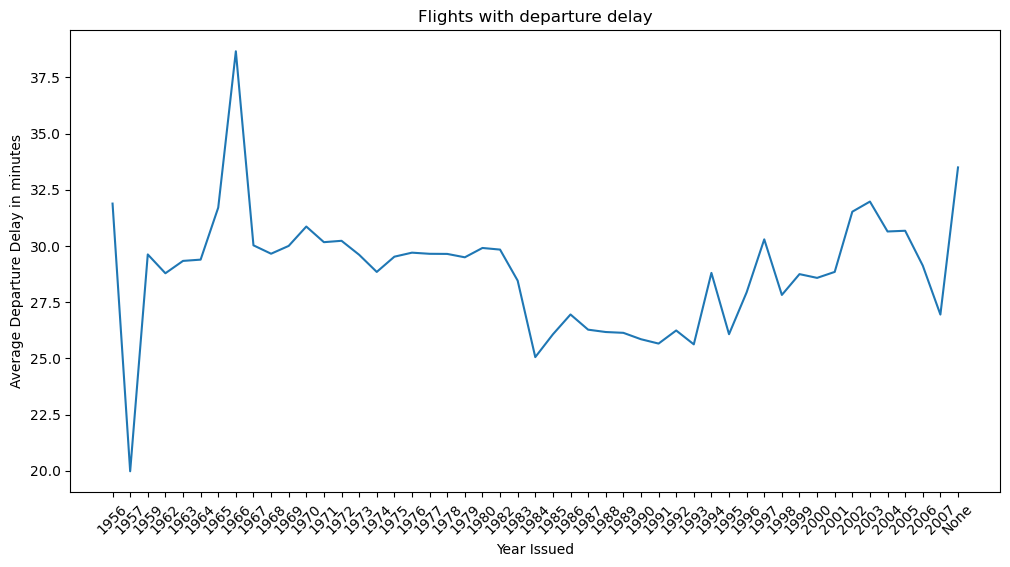

In [102]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(AvgDepDelay_df3['planesyear'], AvgDepDelay_df3['AvgDelay'])
ax.set_xlabel("Year Issued")
ax.set_ylabel("Average Departure Delay in minutes")
plt.xticks(rotation=45)
ax.title.set_text("Flights with departure delay")

# Average arrival delay

In [103]:
AvgArrDelay_df = pd.read_sql('''
 SELECT planes.Year AS planesyear, AVG(flights.ArrDelay) AS AvgDelay
 FROM planes JOIN flights USING (tailnum)
 Where flights.Cancelled = 0 AND flights.Diverted = 0 AND flights.ArrDelay > 0
 GROUP BY planesyear
 ORDER BY planesyear
''', con = conn)
print(AvgArrDelay_df)

   planesyear   AvgDelay
0        None  31.419237
1        0000  24.471573
2        1956  35.430541
3        1957  22.320346
4        1959  31.616762
5        1962  30.556576
6        1963  30.937204
7        1964  31.436511
8        1965  30.871035
9        1966  31.075935
10       1967  25.644669
11       1968  25.992647
12       1969  25.755614
13       1970  26.182243
14       1971  26.911747
15       1972  32.792453
16       1973  27.620449
17       1974  30.639742
18       1975  28.751951
19       1976  27.670554
20       1977  26.872199
21       1978  27.013701
22       1979  27.284279
23       1980  28.174785
24       1982  32.352175
25       1983  29.789298
26       1984  27.763944
27       1985  27.408436
28       1986  28.232208
29       1987  27.749829
30       1988  27.999021
31       1989  28.337245
32       1990  27.847093
33       1991  28.028513
34       1992  27.693617
35       1993  26.427260
36       1994  28.165911
37       1995  26.105930
38       1996  27.060381


In [104]:
AvgArrDelay_df2 = AvgArrDelay_df.dropna()
AvgArrDelay_df3 = AvgArrDelay_df2.drop(labels = 1, axis = 0)

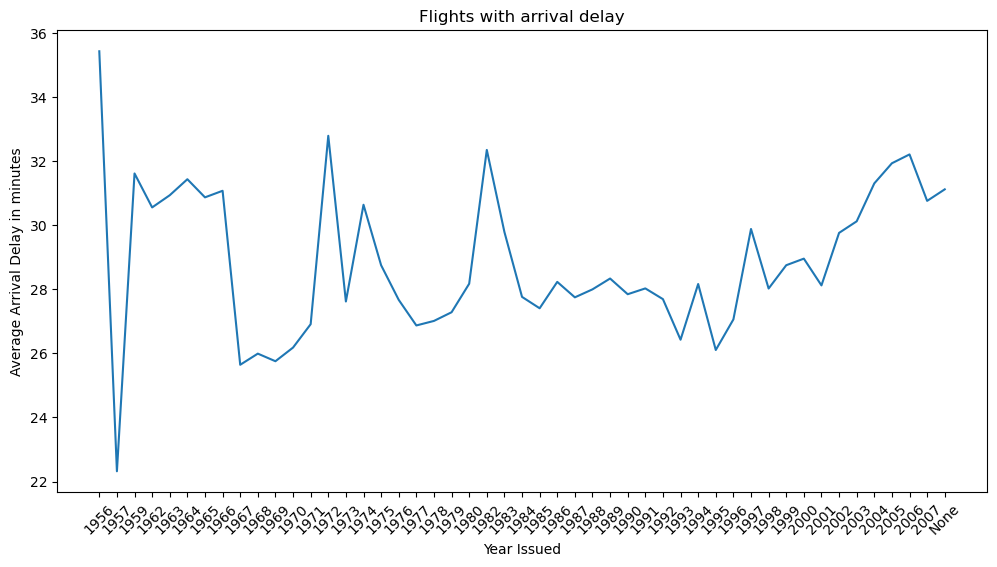

In [106]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(AvgArrDelay_df3['planesyear'], AvgArrDelay_df3['AvgDelay'])
ax.set_xlabel("Year Issued")
ax.set_ylabel("Average Arrival Delay in minutes")
plt.xticks(rotation=45)
ax.title.set_text("Flights with arrival delay")

# Q2c

In [17]:
from sklearn.linear_model import LogisticRegression


In [ ]:
data2001 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2001.csv",encoding='latin1') 
data2004 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2004.csv",encoding='latin1')
data2006 = pd.read_csv(r"C:\Users\user\Documents\st2195\EXTRACT\2006.csv",encoding='latin1')

In [ ]:
data2001.to_sql('flights', con = conn, if_exists = 'append', index = False)
data2004.to_sql('flights', con = conn, if_exists = 'append', index = False)
data2006.to_sql('flights', con = conn, if_exists = 'append', index = False)

In [28]:
conn = sqlite3.connect(':memory:')

In [26]:
# Group by 'Year' and check the number of unique values in 'Diverted'
unique_values = df.groupby('Year')['Diverted'].nunique()

# Print the years that have at least two unique values in 'Diverted'
valid_years = unique_values[unique_values >= 2].index.tolist()
print(valid_years)


[]


In [27]:
for year in [2001, 2004, 2006]:
    print(f"Unique values in 'Diverted' for year {year}: ", df[df['Year'] == year]['Diverted'].unique())


Unique values in 'Diverted' for year 2001:  []
Unique values in 'Diverted' for year 2004:  [1]
Unique values in 'Diverted' for year 2006:  [1]


In [24]:
years = [2001, 2004, 2006]

In [13]:
sql_query = """
    SELECT 
        Diverted,
        Year,
        CRSDepTime,
        CRSArrTime,
        Distance,
        CarrierDelay
    FROM 
        flights
    WHERE
        Year IN (1998,2004,2006) AND Diverted = 1
"""

In [14]:
df = pd.read_sql_query(sql_query, conn)


In [15]:
coefficients = {}

Data for year 2001 contains only one class in 'Diverted'. Skipping...
Data for year 2004 contains only one class in 'Diverted'. Skipping...
Data for year 2006 contains only one class in 'Diverted'. Skipping...


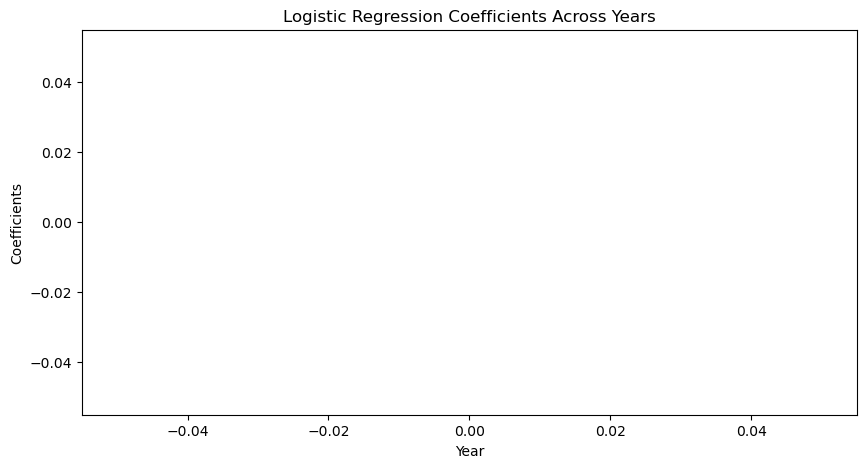

In [25]:
import matplotlib.pyplot as plt

coefficients = {}

for year in years:
    df_year = df[df['Year'] == year]
    
    # Check if df_year has at least two classes in 'Diverted'
    if len(df_year['Diverted'].unique()) < 2:
        print(f"Data for year {year} contains only one class in 'Diverted'. Skipping...")
        continue
    
    # Selecting features
    features = ['CRSDepTime', 'CRSArrTime', 'Distance', 'CarrierDelay']
    X = df_year[features]
    y = df_year['Diverted']
    X.dropna()

    # Fitting the model
    model = LogisticRegression()
    model.fit(X, y)

    # Getting the coefficients
    coefficients[year] = model.coef_[0]

# Visualizing the coefficients
plt.figure(figsize=(10, 5))
plt.plot(list(coefficients.keys()), list(coefficients.values()))
plt.xlabel('Year')
plt.ylabel('Coefficients')
plt.title('Logistic Regression Coefficients Across Years')
plt.show()


